In [11]:
import pandas as pd
csv_path = 'c:/data/test/insurance_regression.csv'
data = pd.read_csv(csv_path)
data.head()

,age,years,accidents,premium
0,20,1,2,185
1,22,2,1,170
2,24,1,0,155
3,26,3,0,145
4,28,4,1,160


In [2]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        20 non-null     int64
 1   years      20 non-null     int64
 2   accidents  20 non-null     int64
 3   premium    20 non-null     int64
dtypes: int64(4)
memory usage: 772.0 bytes
None


In [3]:
X = data[['age','years','accidents']]
y = data['premium']
print(X.head())
print(y.head())

   age  years  accidents
0   20      1          2
1   22      2          1
2   24      1          0
3   26      3          0
4   28      4          1
0    185
1    170
2    155
3    145
4    160
Name: premium, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 7)
print(X_train.shape, X_test.shape)

(16, 3) (4, 3)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

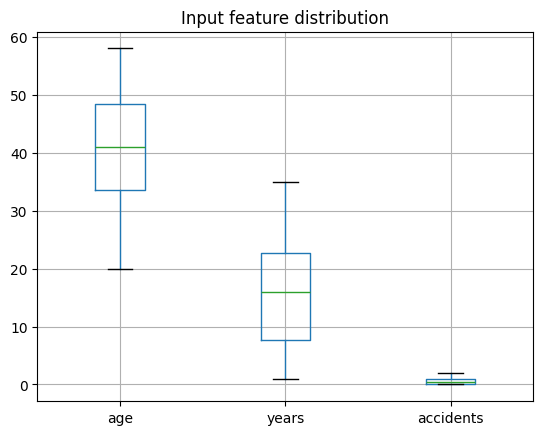

In [6]:
import matplotlib.pyplot as plt
pd.DataFrame(X_train).boxplot()
plt.title('Input feature distribution')
plt.show()

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50
)
hist = model.fit(
    X_train, y_train,
    epochs=500,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 676ms/step - loss: 15108.9326 - mae: 120.6071 - val_loss: 17583.9375 - val_mae: 130.6549
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 15056.8672 - mae: 120.3835 - val_loss: 17541.8984 - val_mae: 130.4839
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 15004.7656 - mae: 120.1593 - val_loss: 17499.8047 - val_mae: 130.3124
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 14952.7549 - mae: 119.9350 - val_loss: 17457.6562 - val_mae: 130.1404
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 14900.6914 - mae: 119.7100 - val_loss: 17415.4453 - val_mae: 129.9678
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 14848.5830 - mae: 119.4844 - val_loss: 17373.1719 - val_mae: 129.7948
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 14796.5420 - mae: 119.2587 - val_loss: 17331.5273 - val_mae: 129.6239
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 14744.4424 - mae: 119.0324 - val_loss: 17290.

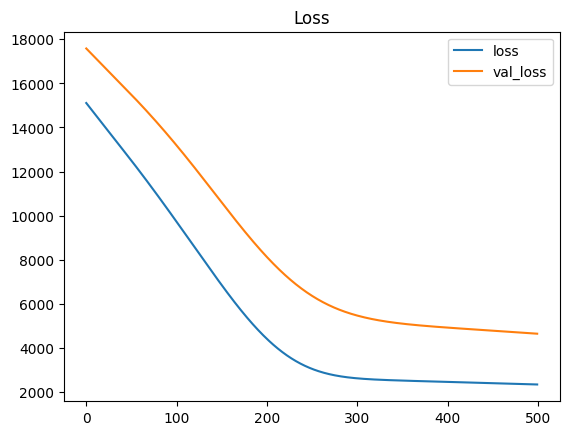

In [8]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.title('Loss')
plt.show()

In [9]:
train_scores = model.evaluate(X_train, y_train)
test_scores = model.evaluate(X_test, y_test)
print('Train scores:', train_scores)
print('Test scores:', test_scores)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2910.9871 - mae: 41.3444
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 7261.6738 - mae: 81.1140
Train scores: [2910.987060546875, 41.34441375732422]
Test scores: [7261.673828125, 81.11398315429688]


In [10]:
from sklearn.metrics import r2_score
pred = model.predict(X_test)
print('R2 score:', r2_score(y_test, pred))
print('실제값:', list(y_test[:5]))
print('예측값:', pred[:5].reshape(-1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
R2 score: -8.166608810424805
실제값: [170, 95, 155, 135]
예측값: [ 55.335938 145.84726   57.065437  73.989975]
